In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MultiLabelBinarizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Netflix Dataset.csv")

# Kolla datatyper
print(df.dtypes)
print(df.head())

Show_Id         object
Category        object
Title           object
Director        object
Cast            object
Country         object
Release_Date    object
Rating          object
Duration        object
Type            object
Description     object
dtype: object
  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                Cast        Country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

        Release_D

In [ ]:
# Filmer: Duration innehåller "min"
movies = df[df['Duration'].str.contains("min", na=False)].copy()
shows = df[df['Duration'].str.contains("Season", na=False)].copy()

# Extrahera minuter och säsonger
movies['Minutes'] = movies['Duration'].str.extract(r'(\d+)').astype(float)
shows['Seasons'] = shows['Duration'].str.extract(r'(\d+)').astype(float)

# Rensa Duration-text
movies['Duration'] = movies['Duration'].str.replace(r'\d+', '', regex=True).str.strip()
shows['Duration'] = shows['Duration'].str.replace(r'\d+', '', regex=True).str.strip()

# Fyll missing description
movies['Description'] = movies['Description'].fillna("")
shows['Description'] = shows['Description'].fillna("")

# Extrahera år
movies['Release_Year'] = pd.to_datetime(movies['Release_Date'], errors='coerce').dt.year.fillna(0).astype(int)
shows['Release_Year'] = pd.to_datetime(shows['Release_Date'], errors='coerce').dt.year.fillna(0).astype(int)


# Kontrollera resultat
print(f"Antal filmer: {movies.shape[0]}")
print(movies[['Title', 'Duration', 'Minutes']].head())

print(f"Antal serier: {shows.shape[0]}")
print(shows[['Title', 'Duration', 'Seasons']].head())


Train: 3227, Val: 1076, Test: 1076
Antal klasser: 15
Klasser: ['G' 'NC-17' 'NR' 'PG' 'PG-13' 'R' 'TV-14' 'TV-G' 'TV-MA' 'TV-PG' 'TV-Y'
 'TV-Y7' 'TV-Y7-FV' 'UR' 'Unknown']


In [41]:
# Splitta 'Type' till listor
movies['Genres'] = movies['Type'].fillna("Unknown").apply(lambda x: [g.strip() for g in x.split(",")])
shows['Genres']  = shows['Type'].fillna("Unknown").apply(lambda x: [g.strip() for g in x.split(",")])

# Multi-hot encoding av genrer
mlb = MultiLabelBinarizer()
genres_movies = mlb.fit_transform(movies['Genres'])
genres_shows  = mlb.transform(shows['Genres'])

# Vanliga kategoriska features (utan 'Type', vi har ersatt den med Genres!)
cat_cols = ['Category', 'Country', 'Rating']
encoder = OneHotEncoder(handle_unknown='ignore')

cat_movies = encoder.fit_transform(movies[cat_cols].fillna('Unknown'))
cat_shows  = encoder.transform(shows[cat_cols].fillna('Unknown'))

# Numeriska features
num_movies = StandardScaler().fit_transform(movies[['Minutes', 'Release_Year']].fillna(0))
num_shows  = StandardScaler().fit_transform(shows[['Seasons', 'Release_Year']].fillna(0))

# TF-IDF på Description med Optuna-parametrar
tfidf = TfidfVectorizer(
    max_features=5550,
    ngram_range=(1, 3),
    min_df=0.09251645750308994,
    max_df=0.9307811828605214,
    stop_words='english'
)
tfidf_movies = tfidf.fit_transform(movies['Description'])
tfidf_shows  = tfidf.transform(shows['Description'])

# ... (kategori + numeriska features som innan) ...

# Kombinera features
X_movies = hstack([tfidf_movies, cat_movies, num_movies])
X_shows  = hstack([tfidf_shows, cat_shows, num_shows])
X_movies = csr_matrix(X_movies)
X_shows  = csr_matrix(X_shows)

# KMeans med Optuna-parametrar
kmeans_movies = KMeans(n_clusters=12, random_state=42)
movies['Cluster'] = kmeans_movies.fit_predict(X_movies)

kmeans_shows = KMeans(n_clusters=3, random_state=42)
shows['Cluster'] = kmeans_shows.fit_predict(X_shows)


In [42]:
# Title → index mapping för snabb lookup
title_to_idx_movies = pd.Series(movies.index.values, index=movies['Title']).to_dict()
title_to_idx_shows  = pd.Series(shows.index.values, index=shows['Title']).to_dict()

# Hjälpfunktion: Hitta liknande filmer/serier
def get_similar(title, top_n=5, is_movie=True):
    if is_movie:
        df_ = movies
        X_ = X_movies
        title_to_idx = title_to_idx_movies
    else:
        df_ = shows
        X_ = X_shows
        title_to_idx = title_to_idx_shows
        
    if title not in title_to_idx:
        return [], []
    
    idx = title_to_idx[title]
    pos = df_.index.get_loc(idx)
    cluster_id = df_.loc[idx, 'Cluster']
    
    # Kandidater i samma kluster
    candidates = df_[(df_['Cluster'] == cluster_id) & (df_.index != idx)].index.tolist()
    
    if len(candidates) < top_n:
        # Fyll på med hela datasetet
        candidates = df_[df_.index != idx].index.tolist()
    
    candidate_pos = [df_.index.get_loc(i) for i in candidates]
    sims = cosine_similarity(X_[pos], X_[candidate_pos]).flatten()
    top_idx = np.argsort(sims)[::-1][:top_n]
    similar_idx = [candidates[i] for i in top_idx]
    
    return df_.loc[similar_idx, 'Title'].tolist(), similar_idx


In [ ]:
# t-SNE visualisering
def plot_tsne(title, top_n=5, is_movie=True):
    if is_movie:
        df_ = movies
        X_ = X_movies
        title_to_idx = title_to_idx_movies
    else:
        df_ = shows
        X_ = X_shows
        title_to_idx = title_to_idx_shows
    
    titles, sim_idx = get_similar(title, top_n, is_movie)
    if len(titles) == 0:
        print("Inga grannar hittades.")
        return
    
    idx = title_to_idx[title]
    pos = df_.index.get_loc(idx)
    sim_positions = [df_.index.get_loc(i) for i in sim_idx]
    
    # PCA → 50D
    X_50d = PCA(n_components=min(50, X_.shape[1]), random_state=42).fit_transform(X_.toarray())
    
    # t-SNE → 2D
    tsne = TSNE(n_components=2, perplexity=min(30, len(df_)-1), random_state=42)
    X_2d = tsne.fit_transform(X_50d)
    
    plt.figure(figsize=(12,8))
    plt.scatter(X_2d[:,0], X_2d[:,1], c='lightgray', alpha=0.3, label='Alla')
    plt.scatter(X_2d[sim_positions,0], X_2d[sim_positions,1], c='blue', s=120, label='Närmaste grannar', edgecolor='black')
    plt.scatter(X_2d[pos,0], X_2d[pos,1], c='red', s=200, label=title, marker='*', edgecolor='black')
    plt.title(f"t-SNE klustervisualisering för '{title}'")
    plt.legend()
    plt.show()
    
    print(f"\nDe {len(titles)} närmaste titlarna till '{title}':")
    for i, t in enumerate(titles, 1):
        print(f"{i}. {t}")


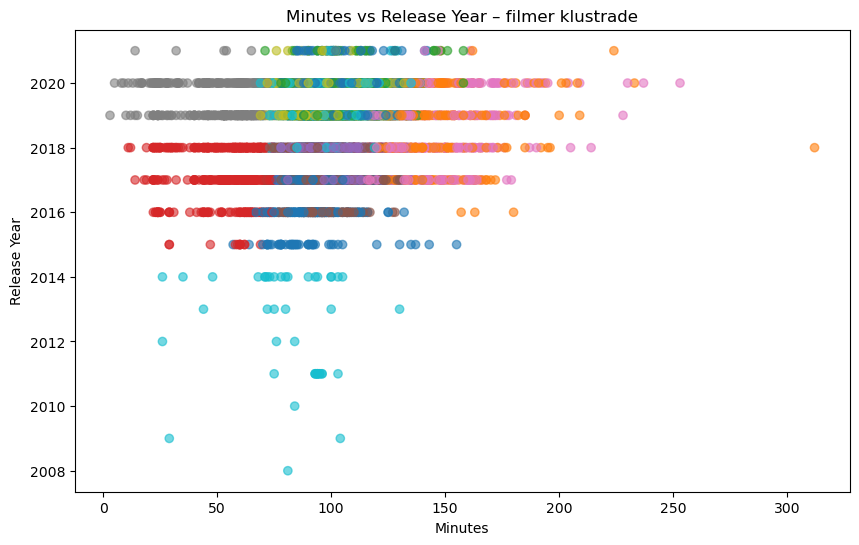

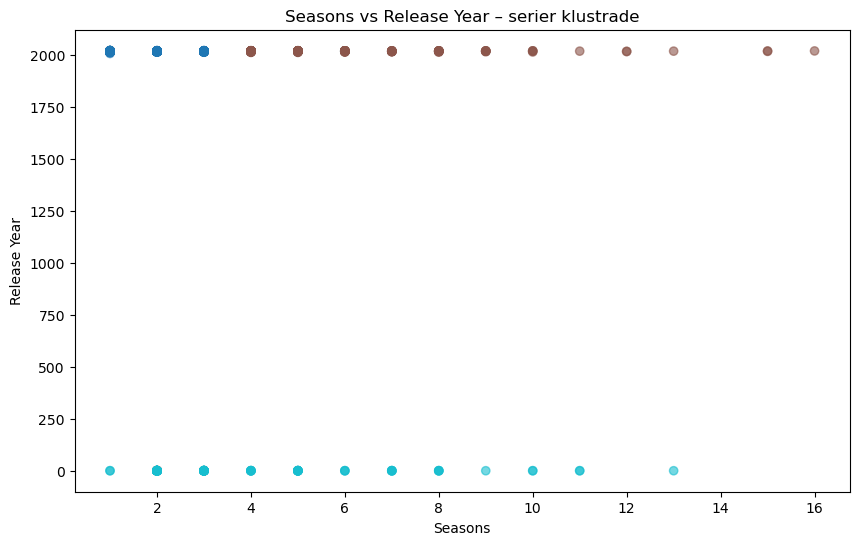

In [43]:
# Exploratory plots
# Minutes vs Release Year
plt.figure(figsize=(10,6))
plt.scatter(movies['Minutes'], movies['Release_Year'], c=movies['Cluster'], cmap='tab10', alpha=0.6)
plt.xlabel("Minutes")
plt.ylabel("Release Year")
plt.title("Minutes vs Release Year – filmer klustrade")
plt.show()

# Se samma för serier
plt.figure(figsize=(10,6))
plt.scatter(shows['Seasons'], shows['Release_Year'], c=shows['Cluster'], cmap='tab10', alpha=0.6)
plt.xlabel("Seasons")
plt.ylabel("Release Year")
plt.title("Seasons vs Release Year – serier klustrade")
plt.show()

In [34]:
for cluster_id, group in movies.groupby("Cluster"):
    all_genres = [genre for sublist in group['Genres'] for genre in sublist]
    genre_counts = Counter(all_genres)
    top_genres = genre_counts.most_common(5)  # topp 5
    print(f"\nCluster {cluster_id}: {len(group)} filmer")
    for genre, count in top_genres:
        print(f"  - {genre}: {count} st")


Cluster 0: 1134 filmer
  - International Movies: 725 st
  - Dramas: 507 st
  - Comedies: 308 st
  - Independent Movies: 225 st
  - Action & Adventure: 180 st

Cluster 1: 1319 filmer
  - Dramas: 467 st
  - Comedies: 459 st
  - Action & Adventure: 248 st
  - Children & Family Movies: 234 st
  - Independent Movies: 219 st

Cluster 2: 761 filmer
  - International Movies: 678 st
  - Dramas: 550 st
  - Comedies: 260 st
  - Action & Adventure: 150 st
  - Romantic Movies: 114 st

Cluster 3: 622 filmer
  - Documentaries: 207 st
  - Stand-Up Comedy: 193 st
  - Children & Family Movies: 145 st
  - International Movies: 69 st
  - Comedies: 54 st

Cluster 4: 969 filmer
  - International Movies: 910 st
  - Dramas: 507 st
  - Comedies: 324 st
  - Romantic Movies: 152 st
  - Independent Movies: 130 st

Cluster 5: 574 filmer
  - Documentaries: 226 st
  - Stand-Up Comedy: 121 st
  - Children & Family Movies: 84 st
  - Comedies: 67 st
  - Dramas: 59 st


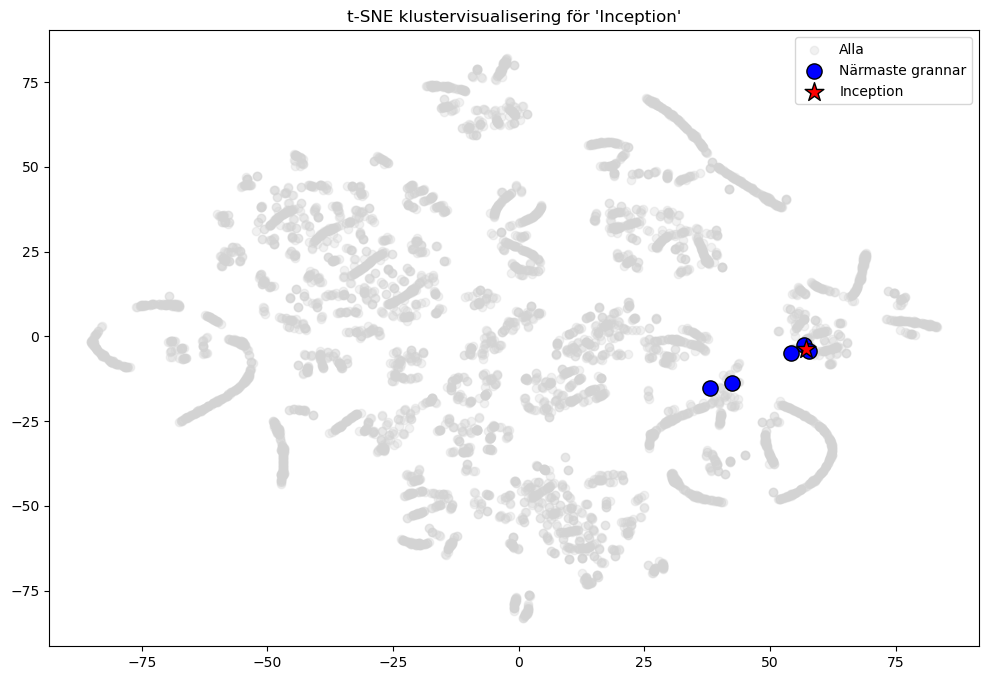


De 5 närmaste titlarna till 'Inception':
1. Across the Universe
2. Les Misérables
3. A Bridge Too Far
4. The Lord of the Rings: The Two Towers
5. The Da Vinci Code


In [44]:
plot_tsne("Inception", top_n=5, is_movie=True)

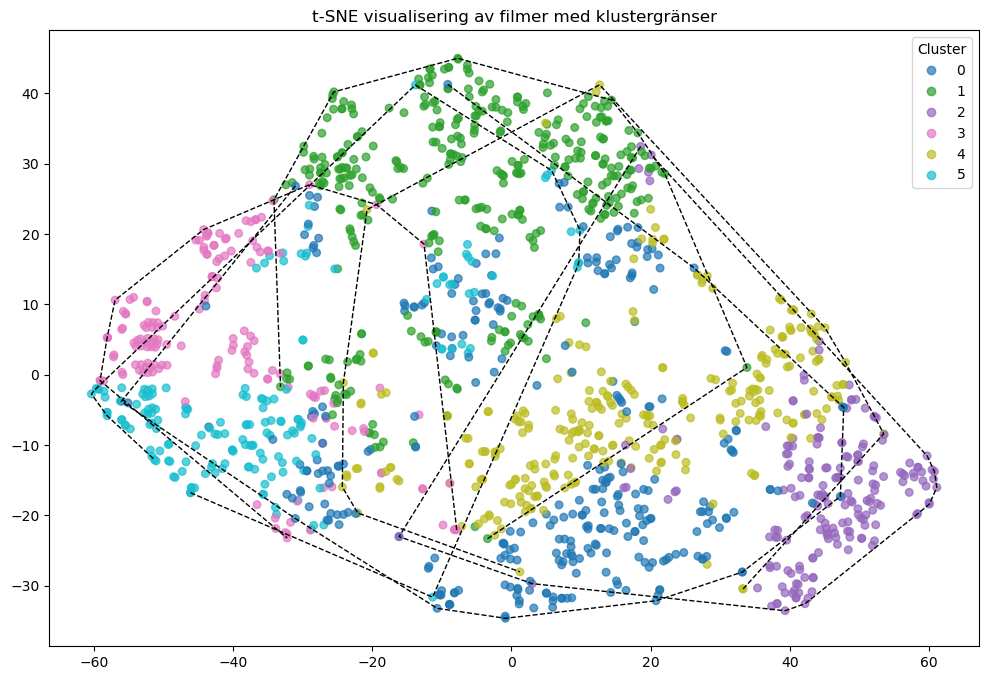

In [36]:
def plot_clusters_with_borders_movies(sample_size=2000):
    # Ta ut sample
    if len(movies) > sample_size:
        sampled_idx = np.random.choice(len(movies), size=sample_size, replace=False)
    else:
        sampled_idx = np.arange(len(movies))

    X_sample = X_movies[sampled_idx].toarray()
    cluster_sample = movies.iloc[sampled_idx]['Cluster'].values

    # PCA → 50D
    X_pca = PCA(n_components=min(50, X_sample.shape[1]), random_state=42).fit_transform(X_sample)

    # t-SNE → 2D
    tsne = TSNE(n_components=2, perplexity=min(30, len(sampled_idx)-1), random_state=42)
    X_2d = tsne.fit_transform(X_pca)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=cluster_sample, cmap="tab10", alpha=0.7, s=30)

    # Rita klustergränser med ConvexHull
    for cluster_id in np.unique(cluster_sample):
        points = X_2d[cluster_sample == cluster_id]
        if len(points) >= 3:
            hull = ConvexHull(points)
            plt.plot(points[hull.vertices,0], points[hull.vertices,1], 'k--', lw=1)

    plt.title("t-SNE visualisering av filmer med klustergränser")
    plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.show()

# Kör den
plot_clusters_with_borders_movies(sample_size=1500)